In [2]:
import geopandas as gpd
from pyproj import CRS
from pathlib import Path

# ---------- locate project root ----------
def find_project_root():
    p = Path.cwd().resolve()
    for parent in [p] + list(p.parents):
        if (parent / "Main data").exists():
            return parent
    raise RuntimeError("Project root (CODE UPLOAD) not found.")

PROJECT_ROOT = find_project_root()
MAIN_DATA = PROJECT_ROOT / "Main data"

# === 读取坐标系（relative）===
crs_path = MAIN_DATA / "roadcrs.txt"
with open(crs_path, "r", encoding="utf-8") as file:
    crs_text = file.read().strip()

roadcrs = CRS.from_string(crs_text)

# === 读取 dz_honeycomb_125（relative）===
shp_path = MAIN_DATA / "dz_honeycomb_125.shp"
gdf_honeycomb = gpd.read_file(shp_path)

# 设置坐标系（如果尚未设置）
if gdf_honeycomb.crs is None:
    gdf_honeycomb.set_crs(roadcrs.to_wkt(), inplace=True)
else:
    gdf_honeycomb = gdf_honeycomb.to_crs(roadcrs.to_wkt())

# === 读取县界（relative）===
county_path = MAIN_DATA / "上海市_县界.shp"
gdf_county = gpd.read_file(county_path)

# 设置坐标系为 roadcrs，并确保与蜂窝数据一致
if gdf_county.crs is None:
    gdf_county.set_crs(roadcrs.to_wkt(), inplace=True)
else:
    gdf_county = gdf_county.to_crs(roadcrs.to_wkt())

# === 筛选“黄浦区”===
huangpu = gdf_county[gdf_county['县级'] == '黄浦区']


         FID                                           geometry
92703  92703  POLYGON ((642257.606 3453667.775, 642257.606 3...
92704  92704  POLYGON ((642041.100 3453667.775, 642041.100 3...
92724  92724  POLYGON ((642582.365 3454230.275, 642582.365 3...
92725  92725  POLYGON ((642149.353 3453855.275, 642149.353 3...
92727  92727  POLYGON ((642365.859 3453855.275, 642365.859 3...
...      ...                                                ...
95466  95466  POLYGON ((641608.087 3458917.775, 641608.087 3...
95468  95468  POLYGON ((641499.834 3459105.275, 641499.834 3...
95469  95469  POLYGON ((641716.340 3459105.275, 641716.340 3...
95475  95475  POLYGON ((641066.821 3459105.275, 641066.821 3...
95476  95476  POLYGON ((640850.315 3459105.275, 640850.315 3...

[561 rows x 2 columns]


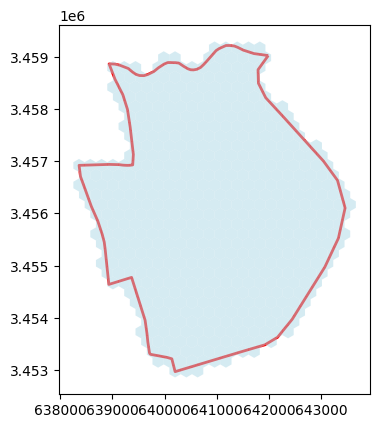

In [6]:
# 找出与黄浦区相交的蜂窝单元
intersected = gdf_honeycomb[gdf_honeycomb.intersects(huangpu.unary_union)]

# 可视化结果
base = huangpu.plot(color='none', edgecolor='red', linewidth=2)
intersected.plot(ax=base, color='lightblue', alpha=0.5)

# 打印结果
print(intersected)


In [7]:
import pandas as pd

# ---------- relative paths ----------
file_path = (
    PROJECT_ROOT
    / "shanghai_data_save"
    / "local_grid_time-series"
    / "completed_tensor.csv"
)

output_path = (
    PROJECT_ROOT
    / "shanghai_data_save"
    / "local_grid_time-series"
    / "completed_tensor_area.csv"
)

# 读取表头（列名）
df_header = pd.read_csv(file_path, nrows=0)
column_names = df_header.columns.tolist()[1:]  # 除去第一列（例如 'batch'）

# 将 intersected['FID'] 转为字符串（与 column_names 一致类型）
fid_columns = [str(fid) for fid in intersected['FID'] if str(fid) in column_names]
print(len(fid_columns))
print(fid_columns)

# 加载原始数据，仅保留需要的列（第一列 + 筛选列）
columns_to_keep = [df_header.columns[0]] + fid_columns  # 保留 'batch' 和匹配的 FID 列
df = pd.read_csv(file_path, usecols=columns_to_keep)

# ✅ 替换所有负值为 0（仅数值列）
df.iloc[:, 1:] = df.iloc[:, 1:].clip(lower=0)

# 保存结果
df.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f"✅ 已保存筛选后的 CSV（负值已设为 0）到: {output_path}")

265
['92973', '92974', '92986', '92989', '92992', '92994', '92995', '92996', '93001', '93002', '93003', '93016', '93017', '93022', '93592', '93597', '93600', '93601', '93621', '93625', '93627', '93629', '93630', '93631', '93632', '93653', '93665', '93666', '93667', '93669', '93671', '93676', '93682', '93684', '93697', '93699', '93700', '93702', '93703', '93707', '93708', '93709', '93711', '93712', '93713', '93714', '93716', '93719', '93723', '93724', '93725', '93727', '93728', '93729', '93730', '93734', '93839', '93840', '93842', '93844', '93845', '93848', '93852', '93855', '93859', '93862', '93863', '93870', '93871', '93872', '93873', '93876', '93885', '93891', '93893', '93897', '93898', '93899', '93901', '93904', '93908', '93909', '93910', '93911', '93912', '93915', '93916', '93918', '93919', '93922', '93924', '93925', '93927', '93932', '93933', '93935', '93936', '93937', '93938', '93939', '93940', '93942', '93943', '93944', '93945', '93948', '93954', '93955', '93958', '93960', '9396